# MATB EEG EDA Notebook

This notebook helps you inspect what the dataset looks like before modeling.

## What this notebook does
- Discovers MATB EEG files across subjects/sessions
- Confirms class/session balance
- Checks channel consistency (63 vs 64 channels)
- Visualizes raw EEG snippets, PSD, and annotation examples
- Summarizes signal-scale statistics for preprocessing decisions

## Run instructions
1. Open this notebook from the project root.
2. Run all cells in order.
3. Review the final recommendation cell before training models.

In [7]:
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 20)

print('mne version:', mne.__version__)

mne version: 1.12.1


In [8]:
DATASET_ROOT = Path('../dataset').resolve()
print('Dataset root:', DATASET_ROOT)

set_files = sorted(DATASET_ROOT.rglob('*.set'))
matb_files = [p for p in set_files if p.stem.lower().startswith('matb')]

rows = []
for p in matb_files:
    subj = next((x for x in p.parts if x.startswith('sub-')), 'unknown')
    ses = next((x for x in p.parts if x.startswith('ses-')), 'unknown')
    level = p.stem.lower().replace('matb', '')
    rows.append({'subject': subj, 'session': ses, 'level': level, 'file': str(p)})

df = pd.DataFrame(rows)
print('Total .set files:', len(set_files))
print('MATB .set files:', len(matb_files))
print('Subjects:', df['subject'].nunique())
print('Sessions:', sorted(df['session'].unique()))
print('Levels:', sorted(df['level'].unique()))

df.head()

Dataset root: C:\Users\u5749675\Desktop\u5749675\eeg-workload-classification\dataset
Total .set files: 261
MATB .set files: 261
Subjects: 29
Sessions: ['ses-S1', 'ses-S2', 'ses-S3']
Levels: ['diff', 'easy', 'med']


,subject,session,level,file
0,sub-01,ses-S1,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...
1,sub-01,ses-S1,easy,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...
2,sub-01,ses-S1,med,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...
3,sub-01,ses-S2,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...
4,sub-01,ses-S2,easy,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...


In [9]:
display(df.groupby('level').size().rename('count').reset_index())
display(df.groupby('session').size().rename('count').reset_index())
display(df.groupby('subject').size().describe().to_frame('files_per_subject'))

triplet_check = (
    df.groupby(['subject', 'session'])['level']
      .apply(lambda s: set(s))
      .reset_index(name='levels_present')
)
missing = triplet_check[triplet_check['levels_present'].apply(lambda s: s != {'easy', 'med', 'diff'})]
print('Missing/non-standard MATB triplets:', len(missing))
display(missing.head(10))

,level,count
0,diff,87
1,easy,87
2,med,87


,session,count
0,ses-S1,87
1,ses-S2,87
2,ses-S3,87


,files_per_subject
count,29.0
mean,9.0
std,0.0
min,9.0
25%,9.0
50%,9.0
75%,9.0
max,9.0


Missing/non-standard MATB triplets: 0


,subject,session,levels_present


C:\Users\u5749675\AppData\Local\Temp\ipykernel_11876\2048130622.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='level', order=sorted(df['level'].unique()), ax=axes[0], palette='Set2')
C:\Users\u5749675\AppData\Local\Temp\ipykernel_11876\2048130622.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='session', order=sorted(df['session'].unique()), ax=axes[1], palette='Set3')


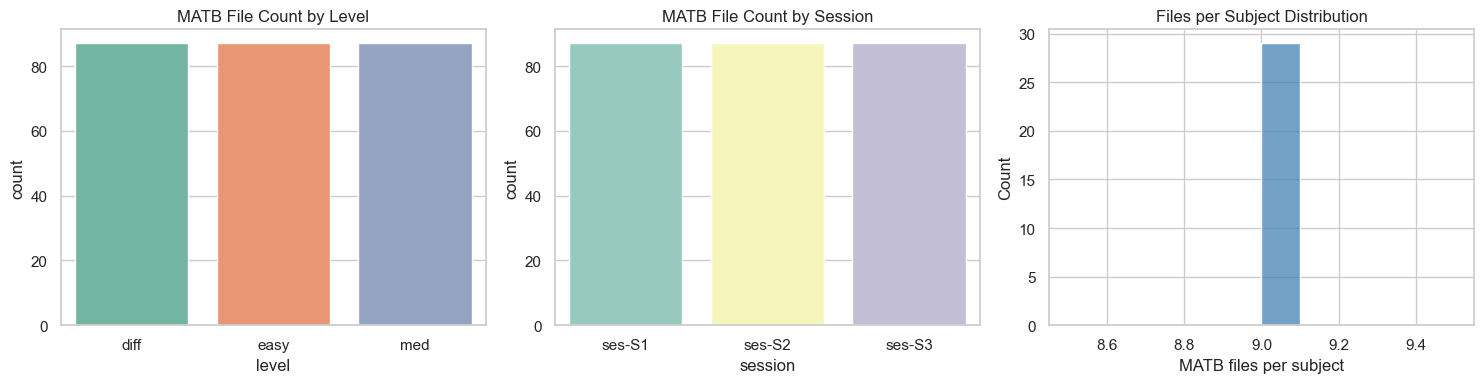

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='level', order=sorted(df['level'].unique()), ax=axes[0], palette='Set2')
axes[0].set_title('MATB File Count by Level')

sns.countplot(data=df, x='session', order=sorted(df['session'].unique()), ax=axes[1], palette='Set3')
axes[1].set_title('MATB File Count by Session')

subject_counts = df.groupby('subject').size().reset_index(name='count')
sns.histplot(subject_counts['count'], bins=10, kde=False, ax=axes[2], color='steelblue')
axes[2].set_title('Files per Subject Distribution')
axes[2].set_xlabel('MATB files per subject')

plt.tight_layout()
plt.show()

In [11]:
channel_counter = Counter()
sfreq_counter = Counter()
durations = []
channels_by_n = {}

for fp in df['file']:
    raw = mne.io.read_raw_eeglab(fp, preload=False, verbose='ERROR')
    n_ch = len(raw.ch_names)
    channel_counter[n_ch] += 1
    sfreq_counter[float(raw.info['sfreq'])] += 1
    durations.append(raw.n_times / raw.info['sfreq'])
    if n_ch not in channels_by_n:
        channels_by_n[n_ch] = raw.ch_names

print('Channel-count distribution:', dict(channel_counter))
print('Sampling-rate distribution:', dict(sfreq_counter))
print('Duration (sec) min/median/max:', np.min(durations), np.median(durations), np.max(durations))

if 63 in channels_by_n and 64 in channels_by_n:
    only_in_64 = sorted(list(set(channels_by_n[64]) - set(channels_by_n[63])))
    only_in_63 = sorted(list(set(channels_by_n[63]) - set(channels_by_n[64])))
    print('Only in 64-channel files:', only_in_64)
    print('Only in 63-channel files:', only_in_63)

Channel-count distribution: {63: 81, 64: 180}
Sampling-rate distribution: {500.0: 261}
Duration (sec) min/median/max: 298.512 299.254 299.7
Only in 64-channel files: ['Cz']
Only in 63-channel files: []


In [12]:
example_file = df.iloc[0]['file']
raw = mne.io.read_raw_eeglab(example_file, preload=True, verbose='ERROR')

print('Example file:')
print(example_file)
print('n_channels:', len(raw.ch_names))
print('sfreq:', raw.info['sfreq'])
print('duration_sec:', raw.n_times / raw.info['sfreq'])
print('annotations:', len(raw.annotations))
raw.info

Example file:
C:\Users\u5749675\Desktop\u5749675\eeg-workload-classification\dataset\sub-01\sub-01\ses-S1\eeg\MATBdiff.set
n_channels: 63
sfreq: 500.0
duration_sec: 299.484
annotations: 1307


<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, ECG1, CP5, CP1, Pz, P3, ...
 chs: 62 EEG, 1 ECG
 custom_ref_applied: False
 dig: 65 items (3 Cardinal, 62 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 63
 projs: []
 sfreq: 500.0 Hz
>

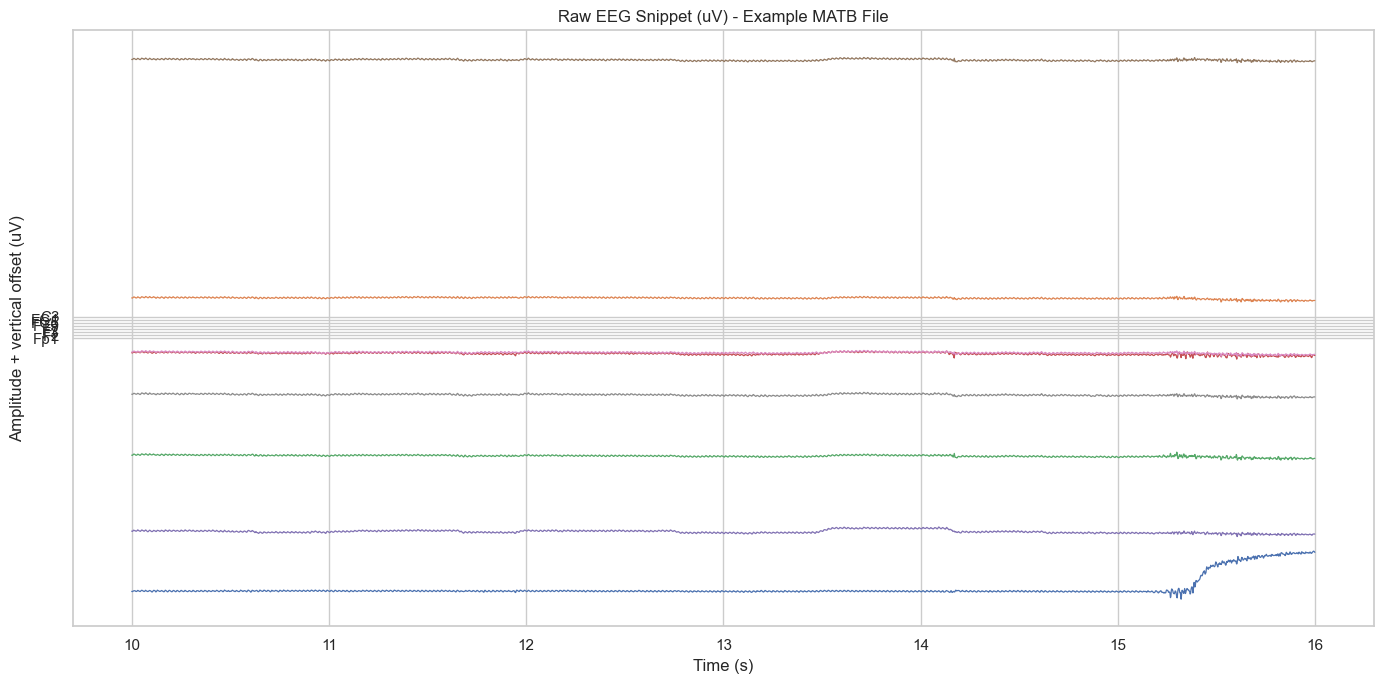

In [13]:
# Plot a short snippet from first 8 EEG-like channels
exclude = {'ECG1', 'ECG2'}
candidate_channels = [ch for ch in raw.ch_names if ch not in exclude][:8]

start_sec = 10
window_sec = 6
sfreq = raw.info['sfreq']
start = int(start_sec * sfreq)
stop = int((start_sec + window_sec) * sfreq)

data, times = raw.get_data(picks=candidate_channels, start=start, stop=stop, return_times=True)
data_uv = data * 1e6

offset = 120.0
plt.figure(figsize=(14, 7))
for i, ch in enumerate(candidate_channels):
    plt.plot(times, data_uv[i] + i * offset, linewidth=0.9, label=ch)

plt.title('Raw EEG Snippet (uV) - Example MATB File')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude + vertical offset (uV)')
plt.yticks([i * offset for i in range(len(candidate_channels))], candidate_channels)
plt.tight_layout()
plt.show()

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


c:\Users\u5749675\Desktop\u5749675\venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


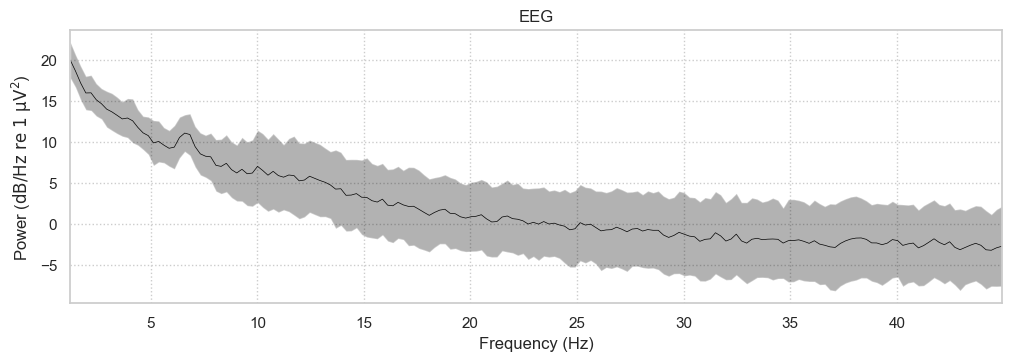

In [14]:
# Power spectral density overview
raw_psd = raw.copy().pick([ch for ch in raw.ch_names if ch not in {'ECG1', 'ECG2'}][:20])
raw_psd.compute_psd(fmin=1, fmax=45).plot(average=True)
plt.show()

In [15]:
ann_df = pd.DataFrame({
    'onset_sec': raw.annotations.onset,
    'duration_sec': raw.annotations.duration,
    'description': raw.annotations.description
})

print('Total annotations:', len(ann_df))
display(ann_df.head(20))

top_ann = ann_df['description'].value_counts().head(15).reset_index()
top_ann.columns = ['description', 'count']
display(top_ann)

Total annotations: 1307


,onset_sec,duration_sec,description
0,0.000,299.484,boundary
1,0.044,0.002,0.56674 KB1 PMP diff 5
2,0.144,0.002,0.66572 KB1 PMP diff 6
3,0.514,0.002,1.036 RESMAN diff 2440 2440 1040 1040
4,0.514,0.002,1.0363 TRACKING diff 1.2114 1.2678
5,1.028,0.002,1.5504 RESMAN diff 2440 2440 1040 1040
6,1.028,0.002,1.5507 TRACKING diff 1.2325 1.0029
7,1.544,0.002,2.0669 RESMAN diff 2380 2380 1080 1080
8,1.546,0.002,2.0672 TRACKING diff 1.1692 -1.5093
9,2.056,0.002,2.5782 RESMAN diff 2380 2380 1080 1080


,description,count
0,boundary,1
1,0.56674 KB1 PMP diff 5,1
2,0.66572 KB1 PMP diff 6,1
3,1.036 RESMAN diff 2440 2440 1040 1040,1
4,1.0363 TRACKING diff 1.2114 1.2678,1
5,1.5504 RESMAN diff 2440 2440 1040 1040,1
6,1.5507 TRACKING diff 1.2325 1.0029,1
7,2.0669 RESMAN diff 2380 2380 1080 1080,1
8,2.0672 TRACKING diff 1.1692 -1.5093,1
9,2.5782 RESMAN diff 2380 2380 1080 1080,1


,mean_abs_uV,std_uV,p95_abs_uV
count,18.000000,18.000000,18.000000
mean,11943.665067,10454.904906,22551.266547
std,5483.192936,10776.942134,6709.142192
min,3081.487162,3869.126681,9827.099609
25%,7920.357380,6416.364704,18017.747803
50%,11519.679450,9163.434902,23302.636719
75%,14469.401346,9338.030466,25349.755859
max,22475.759053,52780.224671,37308.007812


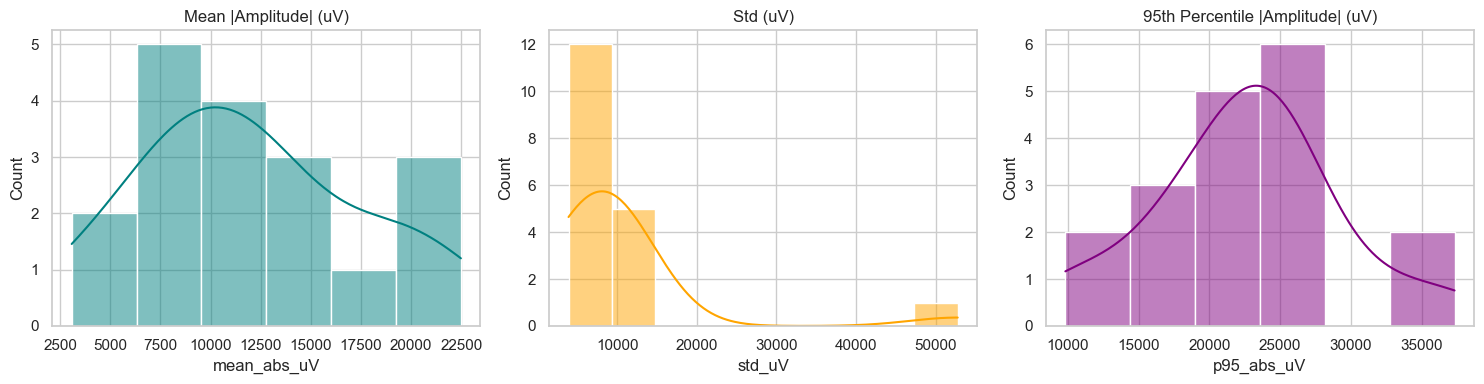

In [16]:
# Signal-scale check on a subset of files to guide preprocessing choices
sample_files = df['file'].sample(n=min(18, len(df)), random_state=42).tolist()
stats = []

for fp in sample_files:
    r = mne.io.read_raw_eeglab(fp, preload=True, verbose='ERROR')
    x = r.get_data() * 1e6  # uV
    stats.append({
        'file': Path(fp).name,
        'mean_abs_uV': float(np.mean(np.abs(x))),
        'std_uV': float(np.std(x)),
        'p95_abs_uV': float(np.percentile(np.abs(x), 95))
    })

stats_df = pd.DataFrame(stats)
display(stats_df.describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(stats_df['mean_abs_uV'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Mean |Amplitude| (uV)')
sns.histplot(stats_df['std_uV'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Std (uV)')
sns.histplot(stats_df['p95_abs_uV'], kde=True, ax=axes[2], color='purple')
axes[2].set_title('95th Percentile |Amplitude| (uV)')
plt.tight_layout()
plt.show()

## EDA-Based Decision for Next Stage

Use these choices for modeling:
- Standardize channels to a common set across all files (drop `Cz` if needed).
- Apply robust preprocessing: bandpass 1-40 Hz, artifact handling, and train-only normalization.
- Segment continuous recordings into fixed windows (for example 2 s with overlap).
- Evaluate using cross-session split (train S1+S2, test S3).

After this notebook, proceed to the modeling notebook with these decisions fixed.